# Unit 2 · Linear models

Course: **21CSC305P — Machine Learning**

## Aim
Use current traffic volume to predict the next hour, then classify light or heavy traffic.

## Assignment tasks
1. Implement linear regression to perform prediction.
2. Implement Bayesian logistic regression and SVM for classification.

## About this transport dataset
This is **real hourly road-sensor data** from westbound Interstate 94 between Minneapolis and Saint Paul, USA. A road sensor counts vehicles passing during each hour. We use **1,008 consecutive hours (42 days), from 13 April 2017 at 10:00 to 25 May 2017 at 09:00**, in the source's local timestamps.

**traffic_volume**: vehicles counted in that hour. **temperature_c**: air temperature in degrees Celsius. **date_time** identifies the hour and is not a numerical model feature.

The original dataset has 48,204 rows and includes weather and holidays from 2012–2018. Repeated weather descriptions can share a timestamp; their traffic counts were verified identical before keeping the first entry. The teaching CSV uses the first six weeks of the longest continuous hourly sequence. Temperature was converted from Kelvin by subtracting 273.15. No missing hours were filled and no measurements were invented.

Source: [UCI Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume). Citation: Hogue, J. (2019), DOI: 10.24432/C5X60B. License: CC BY 4.0. The complete original compressed CSV is included.

**What to tell faculty:** “I am studying traffic patterns using real vehicle counts from a highway sensor.” High vehicle count means a busy hour; without speed or capacity data it does not prove congestion. This small window is a classroom demonstration, not a validation across roads or seasons.

Run cells from top to bottom. Keep the `data` folder beside `notebooks`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/traffic.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/traffic.csv')

df['date_time'] = pd.to_datetime(df['date_time'])
print('Number of traffic hours:', len(df))

Number of traffic hours: 1008


## Prepare the prediction problem
Use this hour’s vehicle count to predict the following hour’s count. `shift(-1)` creates the target, `next_volume`. The last row is removed because its next hour is outside the window. Only current `traffic_volume` is used as input; no future count is passed to the model.

In [2]:
# Each row is exactly one hour after the preceding row.
data = df.copy()
data['next_volume'] = data['traffic_volume'].shift(-1)
data = data.dropna()  # The last hour has no measured following hour.

# Earlier hours teach the model; later hours test it.
split = int(len(data) * 0.8)
train = data.iloc[:split]
test = data.iloc[split:]
print('Training rows:', len(train), '| Testing rows:', len(test))
display(data.head())

Training rows: 805 | Testing rows: 202


,date_time,traffic_volume,temperature_c,next_volume
0,2017-04-13 10:00:00,4576,8.26,5033.0
1,2017-04-13 11:00:00,5033,8.75,5138.0
2,2017-04-13 12:00:00,5138,9.00,5296.0
3,2017-04-13 13:00:00,5296,9.19,5400.0
4,2017-04-13 14:00:00,5400,10.26,5914.0


## Experiment 1 · Linear regression
Fit a straight line: next traffic volume = slope × current traffic volume + intercept. `fit()` learns from training rows; `predict()` gives answers for new rows.

Slope: 0.91
Intercept: 307.03
Mean absolute error: 646.78 vehicles/hour


,actual,predicted
0,722.0,1577.07
1,440.0,964.83
2,287.0,707.91
3,341.0,568.51
4,832.0,617.71


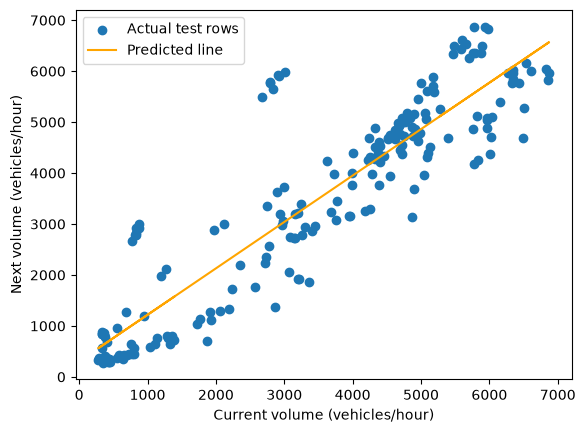

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(train[['traffic_volume']], train['next_volume'])
predicted_volume = model.predict(test[['traffic_volume']])
print('Slope:', round(model.coef_[0], 2))
print('Intercept:', round(model.intercept_, 2))
print('Mean absolute error:', round(mean_absolute_error(test['next_volume'], predicted_volume), 2), 'vehicles/hour')
display(pd.DataFrame({'actual': test['next_volume'].to_numpy()[:5], 'predicted': predicted_volume[:5]}).round(2))

plt.scatter(test['traffic_volume'], test['next_volume'], label='Actual test rows')
plt.plot(test['traffic_volume'], predicted_volume, color='orange', label='Predicted line')
plt.xlabel('Current volume (vehicles/hour)')
plt.ylabel('Next volume (vehicles/hour)')
plt.legend()
plt.show()

## Prepare classification
We turn the target into two categories: **0 = below 4000 vehicles/hour**, **1 = at least 4000 vehicles/hour**. Scaling centers the input around zero. Learn the scaler from training rows only.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# A heavy hour means at least 4000 vehicles. This is a classroom cutoff.
X_train = train[['traffic_volume']]
X_test = test[['traffic_volume']]
y_train = (train['next_volume'] >= 4000).astype(int).to_numpy()
y_test = (test['next_volume'] >= 4000).astype(int).to_numpy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Class 0 = below 4000 vehicles/hour; class 1 = at least 4000 vehicles/hour')

Class 0 = below 4000 vehicles/hour; class 1 = at least 4000 vehicles/hour


## Experiment 2a · Bayesian logistic regression
A logistic curve turns a number into a probability. We try a small grid of intercepts and slopes, give each a Gaussian prior, and calculate how well it explains the training labels. We then average the curves using their posterior weights. This is a simple **grid approximation to Bayesian inference**, using just one input and two parameters. The grid is finite, so the answer is approximate.

In [5]:
x_train = X_train_scaled[:, 0]
x_test = X_test_scaled[:, 0]
parameters = []
scores = []

# Try different intercepts and slopes for the logistic curve.
for intercept in np.linspace(-6, 6, 41):
    for slope in np.linspace(-6, 6, 41):
        probability = 1 / (1 + np.exp(-(intercept + slope * x_train)))
        likelihood = np.sum(y_train * np.log(probability + 1e-12)
                            + (1 - y_train) * np.log(1 - probability + 1e-12))
        prior = -(intercept**2 + slope**2) / 8  # Gaussian prior: variance 4
        parameters.append([intercept, slope])
        scores.append(likelihood + prior)

# Convert scores into posterior weights that add up to one.
weights = np.exp(np.array(scores) - np.max(scores))
weights = weights / weights.sum()
bayes_probability = np.zeros(len(x_test))
for weight, (intercept, slope) in zip(weights, parameters):
    probability = 1 / (1 + np.exp(-(intercept + slope * x_test)))
    bayes_probability += weight * probability

bayes_prediction = (bayes_probability >= 0.5).astype(int)
print('Bayesian logistic accuracy:', round(accuracy_score(y_test, bayes_prediction), 3))

Bayesian logistic accuracy: 0.901


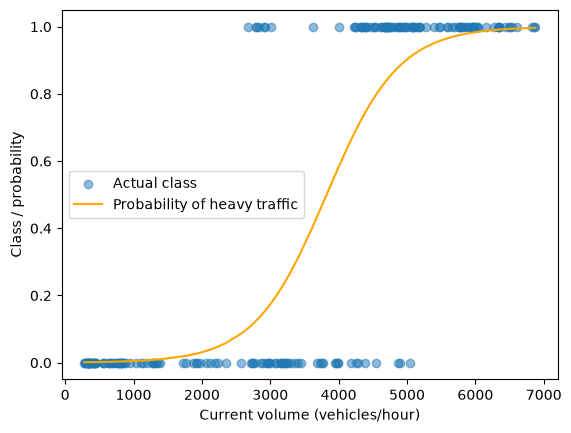

In [6]:
order = np.argsort(test['traffic_volume'].to_numpy())
plt.scatter(test['traffic_volume'], y_test, label='Actual class', alpha=0.5)
plt.plot(test['traffic_volume'].to_numpy()[order], bayes_probability[order], color='orange', label='Probability of heavy traffic')
plt.xlabel('Current volume (vehicles/hour)')
plt.ylabel('Class / probability')
plt.legend()
plt.show()

## Experiment 2b · SVM
An SVM finds a boundary between classes. With one input and a linear kernel, the boundary is a cutoff along the current-volume axis.

SVM accuracy: 0.901


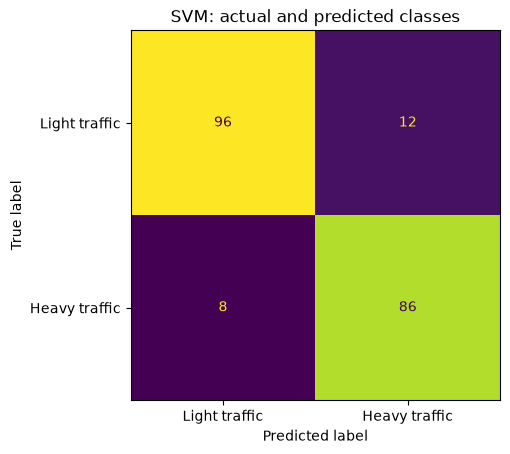

In [7]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train_scaled, y_train)
svm_prediction = svm.predict(X_test_scaled)
print('SVM accuracy:', round(accuracy_score(y_test, svm_prediction), 3))
ConfusionMatrixDisplay.from_predictions(y_test, svm_prediction, display_labels=['Light traffic', 'Heavy traffic'], colorbar=False)
plt.title('SVM: actual and predicted classes')
plt.show()

## What to explain
Regression predicts a number; classification predicts a category. MAE of 500 vehicles/hour means the average absolute error is 500 vehicles/hour. The Bayesian model combines a prior with training evidence and averages possible curves. The 4000 cutoff was chosen before testing and is not an official congestion limit.

**Try:** Predict the next count with `model.predict(pd.DataFrame({"traffic_volume": [3000]}))`.

**Viva:** What are input and target? Why preserve time order? What is a prior? Why does high volume not necessarily mean congestion?